In [3]:
import numpy as np
import swiftsimio as sw
from swiftsimio.visualisation._vistools import (
    _get_projection_field, _get_region_info, _get_rotated_and_wrapped_coordinates,
)
from swiftsimio.visualisation.smoothing_length import backends_get_hsml
from swiftsimio.visualisation.volume_render_backends import backends, backends_parallel

SNAPSHOT = "/cosma8/data/dp004/colibre/Runs/L0012N0376/Thermal_HighCadence/snapshots/colibre_9999/colibre_9999.hdf5"

data = sw.load(SNAPSHOT)
gas = data.gas

m_arr = np.asarray(_get_projection_field(gas, "masses"), dtype=np.float32)
ri = _get_region_info(gas, None, require_cubic=True, periodic=True)
hsml = backends_get_hsml["sph"](gas)
x, y, z = _get_rotated_and_wrapped_coordinates(gas, None, None, True)

# Keep only every 5th particle
idx = slice(None, None, 5)

m_arr = m_arr[idx]
hsml = hsml[idx]
x = x[idx]
y = y[idx]
z = z[idx]

nx = np.asarray(
    ((x - ri["x_min"]) / ri["x_range"]) % ri["periodic_box_x"],
    dtype=np.float32,
)
ny = np.asarray(
    ((y - ri["y_min"]) / ri["y_range"]) % ri["periodic_box_y"],
    dtype=np.float32,
)
nz = np.asarray(
    ((z - ri["z_min"]) / ri["z_range"]) % ri["periodic_box_z"],
    dtype=np.float32,
)
h_arr = np.asarray(hsml / ri["x_range"], dtype=np.float32)

box_x = float(ri["periodic_box_x"])
box_y = float(ri["periodic_box_y"])
box_z = float(ri["periodic_box_z"])

print(f"Loaded {len(nx)} gas particles (20% subsample)")
print(f"box_x={box_x:.4f}  box_y={box_y:.4f}  box_z={box_z:.4f}")

Loaded 10007804 gas particles (20% subsample)
box_x=1.0000  box_y=1.0000  box_z=1.0000


In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt
from swiftsimio.visualisation.volume_render_backends import backends

RESOLUTIONS = 2 ** np.arange(6, 11)  # 64, 128, 256, 512, 1024

times = []

kw = dict(
        x=nx,
        y=ny,
        z=nz,
        m=m_arr,
        h=h_arr,
        res=RESOLUTIONS[0],
        box_x=box_x,
        box_y=box_y,
        box_z=box_z,
    )

#warmup the numba JIT compilers
t0 = time.perf_counter()
out_nested = backends["nested"](**kw, ntarget=6, nlevels=4)
dt = time.perf_counter() - t0

for res in RESOLUTIONS:
    print(f"Running resolution {res}...", flush=True)

    kw = dict(
        x=nx,
        y=ny,
        z=nz,
        m=m_arr,
        h=h_arr,
        res=res,
        box_x=box_x,
        box_y=box_y,
        box_z=box_z,
    )

    t0 = time.perf_counter()
    out_nested = backends["nested"](**kw, ntarget=6, nlevels=4)
    dt = time.perf_counter() - t0

    times.append(dt)

    print(f"  Completed in {dt:.3f} s", flush=True)

times = np.array(times)

plt.figure(figsize=(8, 5))
plt.plot(RESOLUTIONS, times, marker="o")
plt.xscale("log", base=2)
plt.xlabel("Resolution")
plt.ylabel("Wall time [s]")
plt.title("Nested backend scaling with resolution")
plt.grid(True)
plt.tight_layout()
plt.show()

for res, dt in zip(RESOLUTIONS, times):
    print(f"{res:4d}: {dt:.3f} s")

Running resolution 64...
  Completed in 0.354 s
Running resolution 128...
  Completed in 0.681 s
Running resolution 256...


KeyboardInterrupt: 

Numba JIT warmup done.

res = 64
[Python/numba]     357.7 ms
[C++/AVX2]         394.6 ms  (speedup vs numba: 0.91x)
max rel diff:   1.60e-05  (float32 noise expected ~1e-6)

res = 128



[TIMER] ===== nested_grids_cpp  res=64  n=10007804  simd=AVX2 =====
[TIMER]   assign_levels:     18.84 ms  (active_nlevels=0)
[TIMER]   build_hierarchy:    0.00 ms
[TIMER]   allocate:           0.21 ms
[TIMER]   scatter level[0]: 326.53 ms  (10007804 particles, res=64)
[TIMER]   scatter TOTAL:    326.53 ms
[TIMER]   collapse:           0.00 ms
[TIMER]   WALL TOTAL:       345.60 ms
[TIMER] ========================================================



[Python/numba]     684.1 ms



[TIMER] ===== nested_grids_cpp  res=128  n=10007804  simd=AVX2 =====
[TIMER]   assign_levels:     18.79 ms  (active_nlevels=0)
[TIMER]   build_hierarchy:    0.00 ms
[TIMER]   allocate:           1.53 ms
[TIMER]   scatter level[0]: 651.14 ms  (10007804 particles, res=128)
[TIMER]   scatter TOTAL:    651.14 ms
[TIMER]   collapse:           0.00 ms
[TIMER]   WALL TOTAL:       671.46 ms
[TIMER] ========================================================



[C++/AVX2]         718.2 ms  (speedup vs numba: 0.95x)
max rel diff:   2.90e-05  (float32 noise expected ~1e-6)

res = 256
[Python/numba]    2074.4 ms


...

[C++/AVX2]        1995.1 ms  (speedup vs numba: 1.04x)
max rel diff:   3.77e-04  (float32 noise expected ~1e-6)

res = 512
[Python/numba]    6793.0 ms
[C++/AVX2]        5639.0 ms  (speedup vs numba: 1.20x)



[TIMER] ===== nested_grids_cpp  res=512  n=10007804  simd=AVX2 =====
[TIMER]   assign_levels:     20.67 ms  (active_nlevels=2)
[TIMER]   build_hierarchy:    0.00 ms
[TIMER]   allocate:          56.86 ms
[TIMER]   scatter level[0]:4628.08 ms  (9582101 particles, res=512)
[TIMER]   scatter level[1]: 504.90 ms  (425568 particles, res=256)
[TIMER]   scatter level[2]:   6.44 ms  (135 particles, res=128)
[TIMER]   scatter TOTAL:   5139.42 ms
[TIMER]   collapse:         304.64 ms
[TIMER]   WALL TOTAL:      5521.59 ms
[TIMER] ========================================================



max rel diff:   3.67e-04  (float32 noise expected ~1e-6)

res = 1024
[Python/numba]   18494.1 ms
[C++/AVX2]       13453.4 ms  (speedup vs numba: 1.37x)



[TIMER] ===== nested_grids_cpp  res=1024  n=10007804  simd=AVX2 =====
[TIMER]   assign_levels:     28.59 ms  (active_nlevels=3)
[TIMER]   build_hierarchy:    0.01 ms
[TIMER]   allocate:         443.80 ms
[TIMER]   scatter level[0]:6623.62 ms  (7834084 particles, res=1024)
[TIMER]   scatter level[1]:2759.95 ms  (1748017 particles, res=512)
[TIMER]   scatter level[2]: 502.99 ms  (425568 particles, res=256)
[TIMER]   scatter level[3]:   6.17 ms  (135 particles, res=128)
[TIMER]   scatter TOTAL:   9892.73 ms
[TIMER]   collapse:        2478.62 ms
[TIMER]   WALL TOTAL:      12843.74 ms
[TIMER] ========================================================



max rel diff:   3.11e-04  (float32 noise expected ~1e-6)


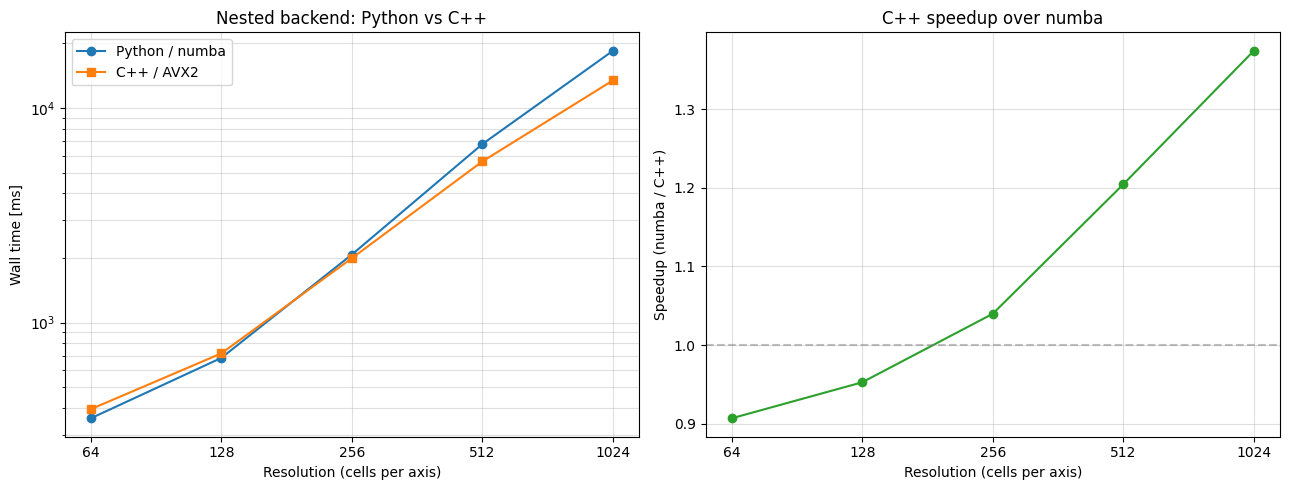


Summary table:
   res    numba [ms]    C++ [ms]   speedup
--------------------------------------------
    64         357.7       394.6      0.91x
   128         684.1       718.2      0.95x
   256        2074.4      1995.1      1.04x
   512        6793.0      5639.0      1.20x
  1024       18494.1     13453.4      1.37x


In [5]:

import time
import numpy as np
import matplotlib.pyplot as plt
from swiftsimio.visualisation.volume_render_backends import backends
from swiftsimio.visualisation.volume_render_backends.nested_grids_cpp import scatter as cpp_scatter

RESOLUTIONS = 2 ** np.arange(6, 11)  # 64, 128, 256, 512  (extend to 1024 if patient)
NTARGET = 6
NLEVELS = 4

# ---- Warmup: JIT-compile numba at small res ----
_kw_warm = dict(x=nx, y=ny, z=nz, m=m_arr, h=h_arr, res=64,
                box_x=box_x, box_y=box_y, box_z=box_z)
_ = backends["nested"](**_kw_warm, ntarget=NTARGET, nlevels=NLEVELS)
print("Numba JIT warmup done.")

times_py  = []
times_cpp = []

for res in RESOLUTIONS:
    kw = dict(x=nx, y=ny, z=nz, m=m_arr, h=h_arr, res=res,
              box_x=box_x, box_y=box_y, box_z=box_z)

    print(f"\n{'='*60}")
    print(f"res = {res}")
    print(f"{'='*60}")

    # ---- Python / numba ----
    t0 = time.perf_counter()
    py_out = backends["nested"](**kw, ntarget=NTARGET, nlevels=NLEVELS)
    dt_py = time.perf_counter() - t0
    times_py.append(dt_py)
    print(f"[Python/numba]  {dt_py*1e3:8.1f} ms")

    # ---- C++ / AVX2 (verbose=True prints per-stage breakdown to stderr) ----
    # Convert positions to float64 as required by the C++ wrapper
    t0 = time.perf_counter()
    cpp_out = cpp_scatter(
        nx.astype(np.float64), ny.astype(np.float64), nz.astype(np.float64),
        m_arr, h_arr, res=res,
        box_x=box_x, box_y=box_y, box_z=box_z,
        ntarget=NTARGET, nlevels=NLEVELS,
        verbose=True,
    )
    dt_cpp = time.perf_counter() - t0
    times_cpp.append(dt_cpp)
    print(f"[C++/AVX2]      {dt_cpp*1e3:8.1f} ms  (speedup vs numba: {dt_py/dt_cpp:.2f}x)")

    # ---- Numerical comparison ----
    diff = np.abs(py_out.astype(np.float64) - cpp_out.astype(np.float64))
    rel  = (diff / (np.abs(py_out).astype(np.float64) + 1e-30)).max()
    print(f"max rel diff:   {rel:.2e}  (float32 noise expected ~1e-6)")

times_py  = np.array(times_py)
times_cpp = np.array(times_cpp)
speedups  = times_py / times_cpp

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(RESOLUTIONS, times_py  * 1e3, marker="o", label="Python / numba")
ax.plot(RESOLUTIONS, times_cpp * 1e3, marker="s", label="C++ / AVX2")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Resolution (cells per axis)")
ax.set_ylabel("Wall time [ms]")
ax.set_title("Nested backend: Python vs C++")
ax.legend()
ax.grid(True, which="both", alpha=0.4)
ax.set_xticks(RESOLUTIONS)
ax.set_xticklabels(RESOLUTIONS)

ax = axes[1]
ax.plot(RESOLUTIONS, speedups, marker="o", color="C2")
ax.axhline(1.0, color="grey", linestyle="--", alpha=0.5)
ax.set_xscale("log", base=2)
ax.set_xlabel("Resolution (cells per axis)")
ax.set_ylabel("Speedup (numba / C++)")
ax.set_title("C++ speedup over numba")
ax.grid(True, which="both", alpha=0.4)
ax.set_xticks(RESOLUTIONS)
ax.set_xticklabels(RESOLUTIONS)

plt.tight_layout()
plt.show()

print("\nSummary table:")
print(f"{'res':>6}  {'numba [ms]':>12}  {'C++ [ms]':>10}  {'speedup':>8}")
print("-" * 44)
for res, tp, tc, sp in zip(RESOLUTIONS, times_py*1e3, times_cpp*1e3, speedups):
    print(f"{res:>6}  {tp:>12.1f}  {tc:>10.1f}  {sp:>8.2f}x")
